In [1]:
from radpy.sedfit import *
from radpy.stellar import *
import pyphot
pyphot.config.set_units_backend('pint')
import dustmaps.sfd
dustmaps.sfd.fetch()

/mnt/c/Users/oxfor/Research/rsadpy/radpy/sedfit.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Holoviews not imported. Some visualizations will not be available.
PyMultiNest not imported.  MultiNest fits will not work.
/home/oxfor/miniforge/envs/test_env/lib/python3.12/site-packages/astroARIADNE/fitter.py:43: UserWarning: (py)MultiNest installation (or libmultinest.dylib) not detected.
  warnings.warn(


Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.
Checking existing file to see if MD5 sum matches ...
File exists. Not overwriting.


In [2]:
starname = 'HD 158259'
star = StellarParams()


In [3]:
ra_deg, dec_deg, ra_hms, dec_hms = pull_coords(starname, star, verbose = True)
gaia_id = pull_gaia_id(starname, star, verbose = True)


Coordinates in decimal degrees for HD 158259:
RA: 261.35023036706, Dec: 52.79068607998

Coordinates in sexagesimal format for HD 158259:
RA: 17:25:24.05529, Dec: 52:47:26.46989
Found Gaia DR3 ID: Gaia DR3 1416050859226670848


In [4]:
photometry = extract_photometry(starname, star, verbose = True)

Star has Gaia DR3 ID.

		#####################################
		##             ARIADNE             ##
		#####################################
   spectrAl eneRgy dIstribution bAyesian moDel averagiNg fittEr

			Author : Jose Vines
			Contact : jose . vines at ug . uchile . cl
			Star : HD 158259
INFO: Query finished. [astroquery.utils.tap.core]
Querying Gaia DR3 for catalog crossmatches...
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog Pan-STARRS.
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog SDSS.
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog APASS.
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog RAVE.
Warning!: CatalogWarning
Warning message: Catalog SkyMapper manually skipped!
Looking online for archival magnitudes for s

In [10]:
out_dir = 'tests/test_data/photometry'
filename = save_photometry('HD158259_test', photometry, out_dir, verbose = True)

Directory 'tests/test_data/photometry' created successfully or already exists.
File saved: /mnt/c/Users/oxfor/Research/rsadpy/tests/test_data/photometry/HD158259_testmags.dat


In [11]:
phot_data = read_in_photometry(filename)

In [12]:
phot_data

index,sed_filter,la,width,flux,eflux
,,Angstrom,Angstrom,erg / (Angstrom s cm2),erg / (Angstrom s cm2)
int64,str17,float64,float64,float64,float64
0,Stromgren.u,3443.6,186.22,-8.312293067898654,0.03633239405994358
1,Stromgren.v,4105.46,111.99,-7.519443432957727,0.033424634820775255
2,TYCHO.TYCHO.B_MvB,4194.96,370.695,-7.438266603920657,0.022513133845333516
3,Johnson.B,4382.77,505.85,-7.362013331800076,0.0219343592986413
4,Stromgren.b,4666.25,101.04,-7.330206282819503,0.03228437277909189
5,GAIA.GAIA3.Gbp,5109.71,1078.75,-7.330221151098504,0.02173310948349352
6,TYCHO.TYCHO.V_MvB,5300.19,566.775,-7.2941748642333835,0.022065092547459583
7,Stromgren.y,5474.17,126.65,-7.310537159431749,0.03204832196456094


In [13]:
logg = 4.21
dlogg = 0.33
m = 0.0
dm = 0.12

star.logg = logg
star.logg_err = dlogg
star.feh = m
star.feh_err = dm


In [14]:
star

fbol = None [10⁻⁸ erg/s/cm²]
fbol_err = None [10⁻⁸ erg/s/cm²]
logg = 4.21 [dex]
logg_err = 0.33 [dex]
feh = 0.0 [dex]
feh_err = 0.12 [dex]
plx = None [mas]
plx_err = None [mas]
dist = None [pc]
dist_err = None [pc]
udthetai = None [mas]
udthetai_err = None [mas]
ldthetai = None [mas]
ldthetai_err = None [mas]
udtheta = None [mas]
udtheta_err = None [mas]
ldtheta = None [mas]
ldtheta_err = None [mas]
teff = None [K]
teff_err = None [K]
lum = None [L☉]
lum_err = None [L☉]
rad = None [R☉]
rad_err = None [R☉]
ldc_R = None [ ]
ldc_K = None [ ]
ldc_H = None [ ]
ldc_J = None [ ]
ra_deg = 261.35023036706
dec_deg = 52.79068607998
ra_hms = 17:25:24.05529
dec_dms = 52:47:26.46989
GaiaDR3ID = 1416050859226670848

In [15]:
D, dD = distances('HD 158259', verbose = True)
star.dist = D
star.dist_err = dD

Found Gaia DR3 ID: Gaia DR3 1416050859226670848
Corrected parallax: 36.99638 [mas]
Distance: 27.02967 +/- 0.01451 [pc]


In [19]:
star.ra = star.ra_hms
star.dec = star.dec_dms

In [21]:
sed_fit = fit_sed(phot_data, star,  [5850, 4.21, 0.0, 0.0],  model = 'phoenix', teffrange = [5000,7000], fitT = True, verbose = True)

Chi squared: 204.54728844817276
Chi squared reduced: 13.636485896544851
Distance: 27.02967 pc
AV: 0.0 mag
Radius: [np.float64(1.3497719662629364)] Rsun
Teff: [np.float64(5555.353860899028)] K
Log g: [4.21] 
Fe/H: 0.0


In [22]:
fbol, fbol_err = calc_fbol(star, sed_fit, 'AA', verbose = True)

Fbol =  6.69999 +/- 0.03007 x10^(-8) erg/s/cm^s/angstrom


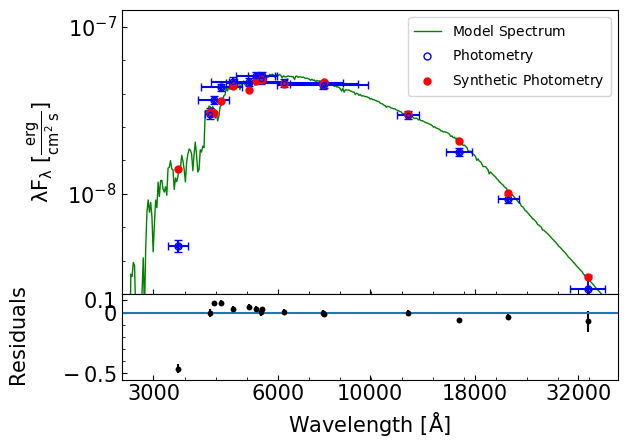

(<Figure size 640x480 with 2 Axes>,
 array([<Axes: ylabel='$\\rm \\lambda F_{\\lambda}~[\\frac{erg}{cm^{2}~s}$]'>,
        <Axes: xlabel='$\\rm Wavelength~[\\AA]$', ylabel='$\\rm Residuals$'>],
       dtype=object))

In [23]:
set_axis = [3.5,4.5, -8.5,-7]
plot_sed(sed_fit, 'AA', logplot = True, fbol_lam = True, set_axis = set_axis, title = None, savefig = None, show = True)

In [6]:
import os
os.getcwd()

'/mnt/c/Users/oxfor/Research/rsadpy'

In [ ]:
import pyphot
pyphot.config.set_units_backend('pint')

In [ ]:
lib = pyphot.get_library()['2MASS_J']

In [ ]:
lib.cl.to('um').magnitude

In [ ]:
np.array(lib.cl.to('micron').magnitude)

In [ ]:
np.array(filt.cl.to('um').magnitude)